# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества
## Стрельченко Алексей Александрович

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** (его выбрал) — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Датасет размеченный: есть признаки (age, sex, bmi, bp, s1–s6) и есть целевая переменная target, которая известна для каждого пациента. Раз ответы есть - это **обучение с учителем (supervised learning)**.

Задача - **регрессия**, потому что предсказываем не категорию, а число. target — это количественная шкала, а не классы. Поэтому используем регрессионные метрики (MSE, RMSE, R²), а не accuracy или F1.

## 2. Загрузка и разведочный анализ данных (EDA)

In [2]:
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
df = data.frame
display(df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
print(f"Размер выборки: {df.shape[0]} объектов, {df.shape[1]} признаков (включая target).")

print("\nТипы признаков:")
display(df.dtypes)

print("\nНаличие пропусков:")
display(df.isna().sum())

print("\nРаспределение target по диапазонам:")
# pd.cut — режет на РАВНЫЕ ПО ШИРИНЕ интервалы (не по количеству!)
y_binned = pd.cut(df['target'], bins=5)
display(y_binned.value_counts().sort_index())

# - базовые статистики (df.describe())
print("\nБазовые статистики:")
display(df.describe().round(4))

Размер выборки: 442 объектов, 11 признаков (включая target).

Типы признаков:


age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


Наличие пропусков:


age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


Распределение target по диапазонам:


target
(24.679, 89.2]    118
(89.2, 153.4]     130
(153.4, 217.6]     91
(217.6, 281.8]     80
(281.8, 346.0]     23
Name: count, dtype: int64


Базовые статистики:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,152.1335
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,77.0930
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378,25.0000
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332,87.0000
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011,140.5000
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279,211.5000
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356,346.0000


**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

**Пропуски**: отсутствуют - во всех колонках count = 442, что равно размеру датасета. Предобработка на заполнение пропусков не требуется.

**Дисбаланс target**: присутствует. При разбиении target на 5 равных диапазонов через pd.cut видно, что данные сконцентрированы в низких значениях. Высокие значения target представлены слабо. Это означает, что модель будет лучше предсказывать низкие значения (там много примеров) и хуже - высокие (там мало примеров). Ошибки на высоких значениях будут систематически больше.

**Масштабы признаков**: одинаковые. У всех признаков mean ≈ 0 и std = 0.0476 - данные уже стандартизированы. Дополнительное масштабирование не обязательно

## 3. Предобработка данных

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [5]:
model_1 = LinearRegression()
model_1.fit(X_train, y_train)

model_2 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
model_2.fit(X_train, y_train)

model_3 = KNeighborsRegressor(n_neighbors=5)
model_3.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [6]:
# Словарь моделей 
models_dict = {
    "Linear Regression": model_1,
    "Decision Tree": model_2,
    "k-NN": model_3
}

metrics_list = []

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    metrics_list.append({
        "model": name,
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

results = pd.DataFrame(metrics_list)
display(results)

,model,MSE,RMSE,R2
0,Linear Regression,2900.19,53.85,0.4526
1,Decision Tree,3526.02,59.38,0.3345
2,k-NN,3019.08,54.95,0.4302


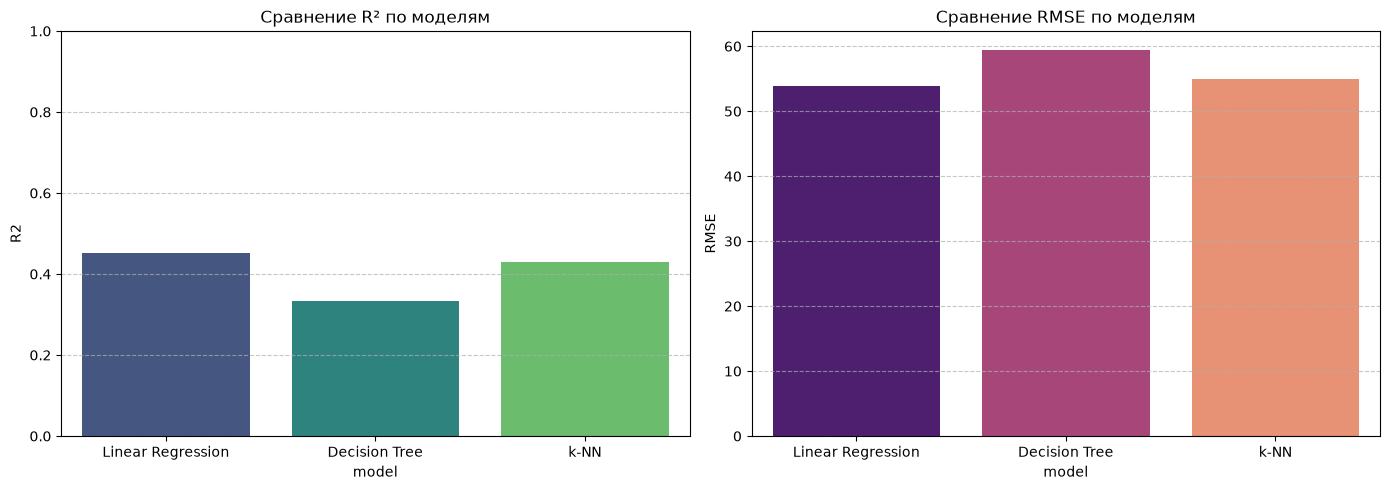

In [7]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=results, x='model', y='R2', hue='model', palette='viridis', legend=False)
plt.title('Сравнение R² по моделям')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(data=results, x='model', y='RMSE', hue='model', palette='magma', legend=False)
plt.title('Сравнение RMSE по моделям')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

**Метрики классификации** (accuracy, precision, recall, F1) здесь не работают - они считают правильные/неправильные попадания в класс, а тут нет классов. Поэтому использованы регрессионные метрики (MSE, RMSE, R²).

**Когда accuracy врёт**: при дисбалансе классов. Если 95% объектов - один класс, модель может всегда его предсказывать и получить accuracy=0.95, не находя второй класс вообще.  Поэтому дополнительно нужно использовать Precision, Recall, F1

## 6. Анализ ошибок

Анализ ошибок для лучшей модели: Linear Regression

Топ-5 объектов с наибольшей абсолютной ошибкой:


,Actual,Predicted,Error,Abs_Error
56,52.0,206.493375,-154.493375,154.493375
77,200.0,71.666726,128.333274,128.333274
211,70.0,179.517208,-109.517208,109.517208
209,77.0,180.390940,-103.390940,103.390940
9,310.0,207.350502,102.649498,102.649498



Средняя ошибка: 3.91
Средняя абсолютная ошибка: 42.79


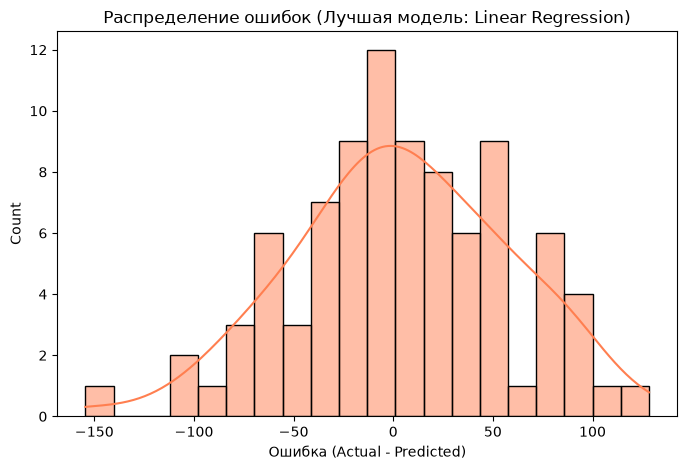

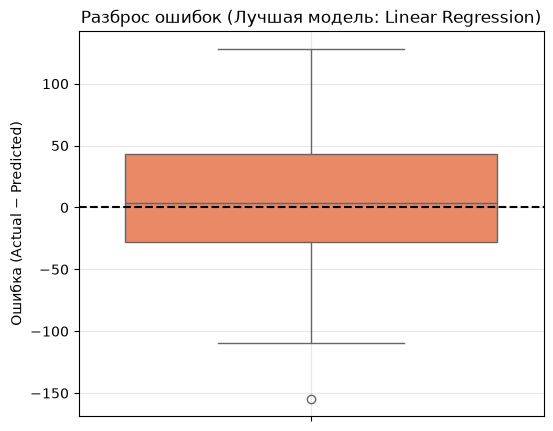

In [11]:
best_model_name = results.loc[results['R2'].idxmax()]['model']
best_model = models_dict[best_model_name]

y_pred_best = best_model.predict(X_test)

errors = y_test - y_pred_best

error_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Error': errors,
    'Abs_Error': np.abs(errors)
})

print(f"Анализ ошибок для лучшей модели: {best_model_name}")
print("\nТоп-5 объектов с наибольшей абсолютной ошибкой:")
display(error_df.sort_values(by='Abs_Error', ascending=False).head())

print("\nСредняя ошибка:", round(errors.mean(), 2))
print("Средняя абсолютная ошибка:", round(np.abs(errors).mean(), 2))

plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True, bins=20, color='coral')
plt.title(f'Распределение ошибок (Лучшая модель: {best_model_name})')
plt.xlabel('Ошибка (Actual - Predicted)')
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(y=errors, color='coral')
plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Ошибка (Actual − Predicted)')
plt.title(f'Разброс ошибок (Лучшая модель: {best_model_name})')
plt.grid(alpha=0.3)
plt.show()

Распределение ошибок лучшей модели (Linear Regression) близко к нормальному с центром около нуля. 
Это означает, что модель несмещённая - ошибается как в сторону завышения, так и в сторону занижения примерно одинаково.
Есть пациенты, для которых модель сильно недооценила target (Actual >> Predicted). Это согласуется с дисбалансом целевой переменной - высоких значений target, поэтому модель хуже их предсказывает.

## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

**Лучшая модель** - Linear Regression. Это ожидаемо: данных мало, признаков немного, и линейка побеждает нелинейные модели - значит, зависимость в данных близка к линейной. Для baseline беру тоже линейную регрессию: она простая, быстрая, интерпретируемая, без гиперпараметров, и даёт лучшее качество. Усложнять смысла нет.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже 

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


In [9]:
# === Задание С2. Классический baseline vs простой MLP ===
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=RANDOM_STATE)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("--- Задание С2 ---")
print(f"R² для Simple MLP: {r2_mlp:.4f}")
print(f"R² для Linear Regression: {results.loc[results['model']=='Linear Regression', 'R2'].values[0]}")


--- Задание С2 ---
R² для Simple MLP: 0.4539
R² для Linear Regression: 0.4526


MLP показала R² = 0.4539 против 0.4526 у линейной регрессии - разница в пределах статистической погрешности, то есть модели практически эквивалентны. При этом MLP требует значительно больше времени на обучение и настройку гиперпараметров. Вывод: на малых табличных данных нейросеть не даёт выигрыша, и простая линейная регрессия предпочтительнее.


--- Задание С4 ---


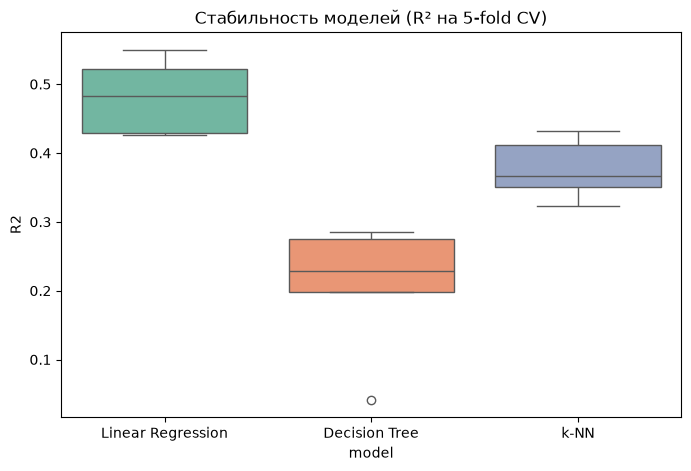

Среднее и стандартное отклонение R² на кросс-валидации:


,mean,std
model,,
Decision Tree,0.206193,0.098409
Linear Regression,0.482316,0.055084
k-NN,0.376508,0.044543


In [10]:
# === Задание С4. Кросс-валидация и доверительный интервал качества ===
cv_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "k-NN": KNeighborsRegressor(n_neighbors=5)
}

cv_results_list = []

for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    for score in scores:
        cv_results_list.append({"model": name, "R2": score})

cv_df = pd.DataFrame(cv_results_list)

print("\n--- Задание С4 ---")
plt.figure(figsize=(8, 5))
sns.boxplot(data=cv_df, x='model', y='R2', hue='model', palette='Set2', legend=False)
plt.title('Стабильность моделей (R² на 5-fold CV)')
plt.show()

print("Среднее и стандартное отклонение R² на кросс-валидации:")
display(cv_df.groupby('model')['R2'].agg(['mean', 'std']))

Кросс-валидация подтвердила результаты одиночного сплита. Линейная регрессия показала лучшее среднее качество при приемлемом разбросе - она надёжна и стабильна. Вывод: линейная регрессия - оптимальный выбор, лучшее качество при достаточной устойчивости.